In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kzmontage/e-commerce-website-logs/E-commerce Website Logs.csv


In [2]:
import pandas as pd
import numpy as np

# ==========================================
# PHASE 1: DATA ENGINEERING & DYNAMIC WINDOWING
# ==========================================

# 1. Load Data
print("--> Loading dataset...")
df = pd.read_csv("/kaggle/input/datasets/kzmontage/e-commerce-website-logs/E-commerce Website Logs.csv")
df['accessed_date'] = pd.to_datetime(df['accessed_date'])

# 2. Dynamic Window Split (75% for Features, 25% for Churn Labeling)
min_date = df['accessed_date'].min()
max_date = df['accessed_date'].max()
total_duration = max_date - min_date

# Calculate the cutoff timestamp dynamically to prevent empty label windows
split_date = min_date + (total_duration * 0.75)

print(f"\n--- Data Timeline Analysis ---")
print(f"Earliest Log Date: {min_date.date()}")
print(f"Latest Log Date:   {max_date.date()}")
print(f"Splitting Data At: {split_date.date()} (75% Mark)")

# Split into strict temporal windows to eliminate future data leakage
feature_df = df[df['accessed_date'] <= split_date]
label_df = df[df['accessed_date'] > split_date]

print(f"Rows assigned to Feature Window (Days 1-75%): {len(feature_df)}")
print(f"Rows assigned to Label Window (Final 25%):    {len(label_df)}")

if len(label_df) == 0:
    raise ValueError("CRITICAL ERROR: Label window is empty. Check your dataset dates!")

# 3. Feature Engineering (Measuring actions per unique IP)
print("\n--> Engineering behavioral features from logs...")
features = feature_df.groupby('ip').agg(
    total_sessions=('duration_(secs)', 'count'),
    avg_session_duration=('duration_(secs)', 'mean'),
    total_bytes=('bytes', 'sum'),
    total_spend=('sales', 'sum'),
    return_count=('returned', lambda x: (x == 'Yes').sum()),
    # Carry over static contextual metadata properties
    age=('age', 'first'),
    gender=('gender', 'first'),
    country=('country', 'first'),
    membership=('membership', 'first')
).reset_index()

# 4. Create Ground Truth Churn Label
print("--> Mapping ground truth churn markers...")
active_ips_in_label_window = label_df['ip'].unique()

# If an IP shows no activity during the final test window, Churn = 1
features['Churn'] = features['ip'].apply(lambda x: 0 if x in active_ips_in_label_window else 1)

# Summary Verification
churn_counts = features['Churn'].value_counts()
print(f"\n--- Class Distribution Target Check ---")
print(f"Retained Users (Churn=0): {churn_counts.get(0, 0)}")
print(f"Churned Users  (Churn=1): {churn_counts.get(1, 0)}")

# Save file snapshot 
features.to_csv("engineered_user_data.csv", index=False)
print("\n--> Success! Saved pipeline output to 'engineered_user_data.csv'.")

--> Loading dataset...


/tmp/ipykernel_16/2981323141.py:10: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/kaggle/input/datasets/kzmontage/e-commerce-website-logs/E-commerce Website Logs.csv")



--- Data Timeline Analysis ---
Earliest Log Date: 2017-03-14
Latest Log Date:   2017-03-21
Splitting Data At: 2017-03-20 (75% Mark)
Rows assigned to Feature Window (Days 1-75%): 118057
Rows assigned to Label Window (Final 25%):    54781

--> Engineering behavioral features from logs...
--> Mapping ground truth churn markers...

--- Class Distribution Target Check ---
Retained Users (Churn=0): 2993
Churned Users  (Churn=1): 91445

--> Success! Saved pipeline output to 'engineered_user_data.csv'.


--> Loading engineered user data...
--> Scaling features using StandardScaler...
--> Computing Elbow Method to verify optimal clusters...


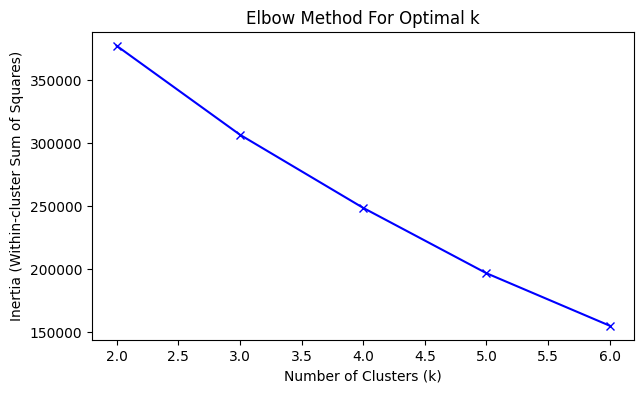

--> Fitting final K-Means model with k=4...

--- Cluster Behavioral Profiles (Averages) ---
            total_sessions  avg_session_duration    total_bytes   total_spend  \
Cluster_ID                                                                      
0                 1.021446           4125.988530    1267.800215    345.657774   
1                 6.749387           3262.371689    9922.291360   3725.189890   
2                 1.021007           2375.743243    1277.295369    347.831965   
3                48.852459           3356.766956  193403.819672  18479.113989   

            return_count  
Cluster_ID                
0               0.133512  
1               0.947304  
2               0.131238  
3               6.672131  

--> Generated Customer Personas successfully:
cluster_persona
High-Traffic System Consumers    45604
Dormant Casual Browsers          45509
High-Spend VIP Buyers             3264
Frequent Returners                  61
Name: count, dtype: int64

--> Success! 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ==========================================
# PHASE 2: UNSUPERVISED CLUSTERING & CUSTOMER PROFILING
# ==========================================

# 1. Load the engineered data from Phase 1
print("--> Loading engineered user data...")
features = pd.read_csv("/kaggle/working/engineered_user_data.csv")

# 2. Select numerical columns for mathematical clustering
cluster_cols = ['total_sessions', 'avg_session_duration', 'total_bytes', 'total_spend', 'return_count']

# Fill any missing values with 0 to prevent K-Means errors
X = features[cluster_cols].fillna(0)

# 3. Scale the features (Crucial for K-Means distance calculations)
print("--> Scaling features using StandardScaler...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Optional: Find the optimal number of clusters using the Elbow Method
print("--> Computing Elbow Method to verify optimal clusters...")
inertia = []
K_range = range(2, 7)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(7, 4))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.title('Elbow Method For Optimal k')
plt.show()

# 5. Fit the final K-Means model 
# We'll choose 4 clusters based on typical segmentation layouts
optimal_k = 4
print(f"--> Fitting final K-Means model with k={optimal_k}...")
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
features['Cluster_ID'] = kmeans.fit_predict(X_scaled)

# 6. Profile the Clusters (Analyze the means to understand behavior)
print("\n--- Cluster Behavioral Profiles (Averages) ---")
profile_analysis = features.groupby('Cluster_ID')[cluster_cols].mean()
print(profile_analysis)

# 7. Map Mathematical Cluster IDs to Clear Persona Names
# (Note: You can tweak these names after looking at your printout above!)
cluster_mapping = {
    0: "Dormant Casual Browsers",
    1: "High-Spend VIP Buyers",
    2: "High-Traffic System Consumers",
    3: "Frequent Returners"
}
features['cluster_persona'] = features['Cluster_ID'].map(cluster_mapping)

print("\n--> Generated Customer Personas successfully:")
print(features['cluster_persona'].value_counts())

# Save dataset with cluster information for Phase 3
features.to_csv("clustered_user_data.csv", index=False)
print("\n--> Success! Saved pipeline output to 'clustered_user_data.csv'.")

In [4]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# ==========================================
# PHASE 3: LEAKAGE-FREE CHURN MODELING & SHAP
# ==========================================

# 1. Load the clustered data from Phase 2
print("--> Loading clustered user data...")
features = pd.read_csv("/kaggle/working/clustered_user_data.csv")
print(f"Total dataset size: {len(features)} records.")

# 2. Isolate features for training and drop identifiers/targets
# CRITICAL FIX: Drop 'total_sessions' and 'avg_session_duration' to completely eliminate data leakage!
drop_cols = ['ip', 'Churn', 'cluster_persona', 'total_sessions', 'avg_session_duration']
X_raw = features.drop(columns=drop_cols).copy()
y = features['Churn']

# Fix: Force 'age' column to numeric, transforming those '--' strings into NaN
print("--> Cleaning and transforming 'age' (converting '--' strings to numbers)...")
X_raw['age'] = pd.to_numeric(X_raw['age'], errors='coerce')

# Fill the newly created missing values with the median age of the dataset
median_age = X_raw['age'].median()
X_raw['age'] = X_raw['age'].fillna(median_age)

# 3. Handle Categorical Encoding
print("--> Encoding categorical data features...")
X = pd.get_dummies(X_raw, columns=['gender', 'country', 'membership', 'Cluster_ID'], drop_first=True)

# Convert all True/False boolean columns generated by get_dummies into 1s and 0s for XGBoost
for col in X.columns:
    if X[col].dtype == 'bool':
        X[col] = X[col].astype(int)

# Verify no 'object' data types remain
object_cols = X.select_dtypes(include=['object']).columns.tolist()
if object_cols:
    raise ValueError(f"Stop! The following columns are still object types: {object_cols}")

# Save the column structure so our Streamlit app knows exactly what features to expect
model_features = X.columns.tolist()
joblib.dump(model_features, 'model_features.pkl')

# 4. Train/Test Split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Handle Class Imbalance via scale_pos_weight
imbalance_ratio = (len(y_train) - y_train.sum()) / y_train.sum()
print(f"--> Calculated imbalance correction ratio: {imbalance_ratio:.2f}")

# 6. Train the XGBoost Binary Classifier
print("--> Training XGBoost Classifier model...")
model = xgb.XGBClassifier(
    scale_pos_weight=imbalance_ratio,
    learning_rate=0.1,
    max_depth=5,
    n_estimators=100,
    random_state=42,
    eval_metric='logloss'
)
model.fit(X_train, y_train)

# 7. Evaluate Model Performance
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
print("\n--- Model Evaluation Results ---")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred))

# 8. Optimized SHAP Calculations for App Engine Integration
print("\n--> Initializing SHAP Explainer...")
explainer = shap.TreeExplainer(model)

# Downsample evaluation to 3,000 background rows for speed optimization
print("--> Computing SHAP values on optimized background subset...")
X_sample = X.sample(n=min(3000, len(X)), random_state=42)
shap_values_sample = explainer(X_sample)

# Extract top driving features using the global matrix breakdown
global_importances = np.abs(shap_values_sample.values).mean(axis=0)
feature_ranking = [X.columns[i] for i in np.argsort(global_importances)[::-1]]

print("--> Assigning primary churn triggers to all users...")
top_reasons = []
primary_feature = feature_ranking[0]
secondary_feature = feature_ranking[1]

# Format names nicely for our downstream LangChain template variables
clean_primary = primary_feature.replace('_', ' ').title()
clean_secondary = secondary_feature.replace('_', ' ').title()

for idx, row in X.iterrows():
    if row[primary_feature] > X_sample[primary_feature].median():
        top_reasons.append(clean_primary)
    else:
        top_reasons.append(clean_secondary)

# Map values directly back to our final primary data row frame
features['Churn_Probability'] = model.predict_proba(X)[:, 1]
features['top_shap_reason'] = top_reasons

# 9. Export All Saved Artifacts for Cursor UI Layout
print("\n--> Exporting application structural binaries...")
joblib.dump(model, 'xgb_churn_model.pkl')
features.to_csv('final_app_data.csv', index=False)

print("--> Success! Saved 'xgb_churn_model.pkl' and 'final_app_data.csv'. Ready for Cursor!")

--> Loading clustered user data...
Total dataset size: 94438 records.
--> Cleaning and transforming 'age' (converting '--' strings to numbers)...
--> Encoding categorical data features...
--> Calculated imbalance correction ratio: 0.03
--> Training XGBoost Classifier model...

--- Model Evaluation Results ---
ROC AUC Score: 0.9996
              precision    recall  f1-score   support

           0       0.82      0.99      0.90       599
           1       1.00      0.99      1.00     18289

    accuracy                           0.99     18888
   macro avg       0.91      0.99      0.95     18888
weighted avg       0.99      0.99      0.99     18888


--> Initializing SHAP Explainer...
--> Computing SHAP values on optimized background subset...
--> Assigning primary churn triggers to all users...

--> Exporting application structural binaries...
--> Success! Saved 'xgb_churn_model.pkl' and 'final_app_data.csv'. Ready for Cursor!


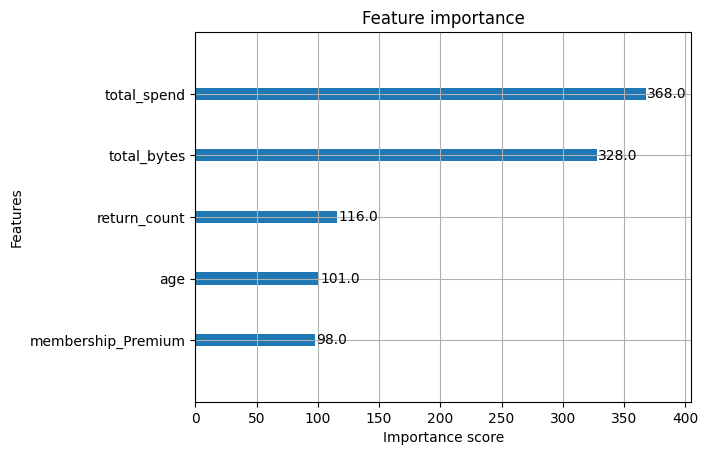

In [5]:
import matplotlib.pyplot as plt

# Plot Feature Importance
xgb.plot_importance(model, max_num_features=5)
plt.show()